In [43]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import overload
from datetime import datetime
from copy import deepcopy
import os

SEED = 64
torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams["font.family"] = "Open Sans"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Imports loaded.")

# loaded cell exec order:
# 0, 1, 2, 3, 4, 5, 6, 7, 11, 12, 16, 21, 24, 26, 32, 36, 9, 37

Using device: cpu
Imports loaded.


In [44]:
GAMMA = 1.4
X_START, X_THROAT, X_LENGTH = 0.0, 0.5, 1.0
X_SHOCK_REF = 0.75  # reference/expected shock location
x_shock = 0.75  # initial single_loss_historyguess, updated after shock detection

# pseudo-time horizon: run long enough that transient has died out
T_STEADY = 5.0  # evaluate steady state at this pseudo-time
T_MAX = T_STEADY  # domain upper bound in t

BD_DELTA = 1e-5  # mask width for inlet/exit/IC point selection
EVAL_PRED_POINTS = 2000  # number of points to evaluate the final solution

# ── shock detection hyper-parameters ──────────────────────────────────────────
SHOCK_DET_POINTS = 2000
SHOCK_DET_ADAM_EPOCHS = 1500
SHOCK_DET_LBFGS_EPOCHS = 500
SHOCK_DET_ADAM_LR = 1e-3
SHOCK_DET_RESAMPLE_EVERY = 500
SHOCK_DET_LBFGS_RESAMPLE_EVERY = 500
SHOCK_DET_PRINT_EVERY = 500
SHOCK_DET_GRAD_CLIP = 1.0
SHOCK_DET_BC_WEIGHT = 10.0
SHOCK_FORMATION_TOL = 1e-1

# ── dual-network hyper-parameters ─────────────────────────────────────────────
DUAL_NET_POINTS = 1000
DUAL_NET_TIME_SAMPLES = 200
DUAL_NET_ADAM_EPOCHS = 1500
DUAL_NET_LBFGS_EPOCHS = 500
DUAL_NET_ADAM_LR = 1e-3
DUAL_NET_SHOCK_LR = 1e-4
DUAL_NET_RESAMPLE_EVERY = 1000
DUAL_NET_LBFGS_RESAMPLE_EVERY = 1000
DUAL_MAX_CONSECUTIVE_NAN = 5
DUAL_NET_PRINT_EVERY = 500
DUAL_NET_GRAD_CLIP = 1.0
DUAL_NET_BC_WEIGHT = 10.0
DUAL_NET_INTERFACE_WEIGHT = 10.0
DUAL_NET_SHOCK_PRIOR_WEIGHT = 5.0

REMESH_EVERY = 600  # re-mesh every this many epochs during dual-net training
REMESH_SHIFT_TOL = 1e-3

SNAPSHOT_EVERY = 25          # epochs between field snapshots
SNAPSHOT_N_X   = 400         # number of x points to save in field snapshots

SHOCK_DET_MODEL_NAME = "shock_det_model"
DUAL_NET_PRE_MODEL_NAME = "dual_net_pre_model"
DUAL_NET_POST_MODEL_NAME = "dual_net_post_model"
INTERFACE_MODEL_NAME = "interface_model"


@overload
def get_area(x: float) -> float: ...
@overload
def get_area(x: np.ndarray) -> np.ndarray: ...
@overload
def get_area(x: torch.Tensor) -> torch.Tensor: ...
def get_area(x):
    return 1.0 + 2.2 * (x - X_THROAT) ** 2.0


@overload
def get_d_area(x: float) -> float: ...
@overload
def get_d_area(x: np.ndarray) -> np.ndarray: ...
@overload
def get_d_area(x: torch.Tensor) -> torch.Tensor: ...
def get_d_area(x):
    return 4.4 * (x - X_THROAT)


print("Constants defined.")

Constants defined.


In [45]:
def _bisection_for_mach_no(a: float, supersonic: bool) -> float:
    def func(M):
        t = 1.0 + (GAMMA - 1.0) / 2.0 * M**2.0
        expo = (GAMMA + 1.0) / (2.0 * (GAMMA - 1.0))
        return (1.0 / M) * (2.0 / (GAMMA + 1.0) * t) ** expo - a

    low, high = (1.0 + BD_DELTA, 10.0) if supersonic else (BD_DELTA, 1.0 - BD_DELTA)
    for _ in range(300):
        mid = (low + high) / 2
        if func(mid) * func(low) < 0:
            high = mid
        else:
            low = mid
    return (low + high) / 2


class AnalyticSolution:
    def __init__(self, n_points: int = EVAL_PRED_POINTS):
        self.x_shock = X_SHOCK_REF
        self.x = np.linspace(X_START, X_START + X_LENGTH, n_points)
        self._solve()

    def _solve(self):
        x, x_shock = self.x, self.x_shock
        A = get_area(x)
        M = np.empty_like(x)

        sub_mask = x <= X_THROAT
        pre_mask = (x > X_THROAT) & (x <= x_shock)
        post_mask = x > x_shock

        for i in np.where(sub_mask)[0]:
            M[i] = _bisection_for_mach_no(A[i].item(), supersonic=False)
        for i in np.where(pre_mask)[0]:
            M[i] = _bisection_for_mach_no(A[i].item(), supersonic=True)

        M1 = _bisection_for_mach_no(get_area(x_shock), supersonic=True)
        M2 = np.sqrt(
            (1.0 + (GAMMA - 1.0) / 2.0 * M1**2.0)
            / (GAMMA * M1**2.0 - (GAMMA - 1.0) / 2.0)
        )

        p02_by_p01 = (
            (((GAMMA + 1.0) * M1**2.0) / (2.0 + (GAMMA - 1.0) * M1**2.0))
            ** (GAMMA / (GAMMA - 1.0))
        ) * (
            ((GAMMA + 1.0) / (2.0 * GAMMA * M1**2.0 - GAMMA + 1.0))
            ** (1.0 / (GAMMA - 1.0))
        )

        a_star_2_by_a_star_1 = 1.0 / p02_by_p01

        for i in np.where(post_mask)[0]:
            a_eff = A[i] / a_star_2_by_a_star_1
            M[i] = _bisection_for_mach_no(a_eff, supersonic=False)

        T0 = np.ones_like(x)
        P0 = np.where(post_mask, p02_by_p01, 1.0)
        rho0 = P0 / T0

        T = T0 / (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0)
        P = P0 * (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0) ** (-GAMMA / (GAMMA - 1.0))
        rho = rho0 * (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0) ** (-1.0 / (GAMMA - 1.0))

        self.M, self.P, self.T, self.rho = M, P, T, rho
        self.sub_mask, self.pre_mask, self.post_mask = sub_mask, pre_mask, post_mask
        self.M1, self.M2, self.p02_by_p01 = M1, M2, p02_by_p01
    
    def data(self, region: str):
        match region:
            case "subsonic": mask = self.sub_mask
            case "supersonic": mask = self.pre_mask
            case "post-shock": mask = self.post_mask
            case _:
                raise ValueError(f"Unknown region: {region}")
        
        return self.x[mask], (self.M[mask], self.P[mask], self.T[mask], self.rho[mask])


analytic = AnalyticSolution()
_M_INLET = _bisection_for_mach_no(get_area(X_START), supersonic=False)
RHO_INLET = (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0) ** (-1.0 / (GAMMA - 1.0))
T_INLET = 1.0 / (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0)
P_INLET = RHO_INLET * T_INLET
U_INLET = _M_INLET * np.sqrt(GAMMA * T_INLET)
P_EXIT = analytic.P[-1]

print(f"P_EXIT={P_EXIT:.4f}  U_INLET={U_INLET:.4f}")
print("Analytical reference solution computed.")

P_EXIT=0.8289  U_INLET=0.4804
Analytical reference solution computed.


In [46]:
class UnsteadyNet(nn.Module):
    """
    (x, t) -> (rho, u, P, T)
    """

    INPUT = 2
    OUTPUT = 4

    def __init__(self, hid_dim: int = 128, num_hidden: int = 3):
        super().__init__()
        layers = [nn.Linear(self.INPUT, hid_dim), nn.Tanh()]
        for _ in range(num_hidden):
            layers += [nn.Linear(hid_dim, hid_dim), nn.Tanh()]
        layers += [nn.Linear(hid_dim, self.OUTPUT)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="tanh")
                nn.init.zeros_(m.bias)

    def forward(self, xt: torch.Tensor):
        out = self.net(xt)
        rho_raw, u_raw, p_raw, T_raw = (
            out[:, 0:1],
            out[:, 1:2],
            out[:, 2:3],
            out[:, 3:4],
        )

        rho = nn.functional.softplus(rho_raw + 1.0)
        u = nn.functional.softplus(u_raw)
        P = nn.functional.softplus(p_raw + 1.0)
        T = nn.functional.softplus(T_raw + 1.0)

        return torch.cat([rho, u, P, T], dim=1)


print("UnsteadyNet defined.")

UnsteadyNet defined.


In [47]:
def sample_points(
    x_low: float,
    x_high: float,
    t_low: float = 0.0,
    t_high: float = T_MAX,
    n: int = SHOCK_DET_POINTS,
    ic_frac: float = 0.05,
    bc_frac: float = 0.05,
) -> torch.Tensor:
    n_ic = max(1, int(n * ic_frac))
    n_bc = max(1, int(n * bc_frac))
    n_int = n - 2 * n_bc - n_ic

    # interior
    x_int = torch.rand(n_int, 1, device=device) * (x_high - x_low) + x_low
    t_int = torch.rand(n_int, 1, device=device) * (t_high - t_low) + t_low

    # inlet BC  (x = x_low, t ∈ [t_low, t_high])
    x_in = torch.full((n_bc, 1), x_low, device=device)
    t_in = torch.rand(n_bc, 1, device=device) * (t_high - t_low) + t_low

    # outlet BC (x = x_high, t ∈ [t_low, t_high])
    x_out = torch.full((n_bc, 1), x_high, device=device)
    t_out = torch.rand(n_bc, 1, device=device) * (t_high - t_low) + t_low

    # IC (t = 0, x ∈ [x_low, x_high])
    x_ic = torch.rand(n_ic, 1, device=device) * (x_high - x_low) + x_low
    t_ic = torch.zeros(n_ic, 1, device=device)

    xt = torch.cat(
        [
            torch.cat([x_int, t_int], dim=1),
            torch.cat([x_in, t_in], dim=1),
            torch.cat([x_out, t_out], dim=1),
            torch.cat([x_ic, t_ic], dim=1),
        ],
        dim=0,
    )

    idx = torch.randperm(xt.shape[0], device=device)
    return xt[idx].requires_grad_(True)


print("Point sampler defined.")

Point sampler defined.


In [48]:
def _grad(f: torch.Tensor, xt: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    g = torch.autograd.grad(f.sum(), xt, create_graph=True)[0]
    return g[:, 0:1], g[:, 1:2]


class UnsteadyLoss:
    @staticmethod
    def pde(model: UnsteadyNet, xt: torch.Tensor):
        """
        - A * drho/dt - A * u * drho/dx - A * rho * du/dx - rho * u * dA/dx = 0
        - A * (rho * (du/dt + u * du/dx) + dP/dx) = 0
        - rho * A * (dT/dt + u * dT/dx) + (GAMMA - 1) * P * (A * du/dx + dA/dx * u) = 0
        - P - rho * T = 0
        """
        out = model(xt)
        rho, u, P, T = out[:, 0:1], out[:, 1:2], out[:, 2:3], out[:, 3:4]
        x = xt[:, 0:1]
        A, A_x = get_area(x), get_d_area(x)

        rho_x, rho_t = _grad(rho, xt)
        u_x, u_t = _grad(u, xt)
        P_x, _ = _grad(P, xt)
        T_x, T_t = _grad(T, xt)

        mass = A * rho_t + A * u * rho_x + A * rho * u_x + rho * u * A_x
        momentum = A * (rho * (u_t + u * u_x) + P_x)
        energy = rho * A * (T_t + u * T_x) + (GAMMA - 1.0) * P * (A * u_x + A_x * u)
        ideal = P - rho * T

        return torch.cat([mass, momentum, energy, ideal], dim=1)

    @staticmethod
    def bc(model: UnsteadyNet, xt: torch.Tensor, side: str = "all"):
        """
        Soft BCs — boundary penalties for a single subdomain.
        side: "left", "right", or "all".
        """
        out = model(xt)
        rho, u, P, T = out[:, 0], out[:, 1], out[:, 2], out[:, 3]
        x, t = xt[:, 0], xt[:, 1]

        zero = torch.tensor(0.0, device=device)

        # inlet BC is only relevant on the left subdomain
        in_mask = (x < BD_DELTA) & (t >= BD_DELTA)
        inlet_loss = (
            (
                (rho[in_mask] / RHO_INLET - 1.0).pow(2).mean()
                + (u[in_mask] - U_INLET).pow(2).mean()
                + (P[in_mask] / P_INLET - 1.0).pow(2).mean()
                + (T[in_mask] / T_INLET - 1.0).pow(2).mean()
            )
            if in_mask.any()
            else zero
        )

        # outlet BC is only relevant on the right subdomain
        out_mask = x > 1.0 - BD_DELTA
        outlet_loss = ((P[out_mask] / P_EXIT - 1.0).pow(2).mean()) if out_mask.any() else zero

        # IC applies on the full domain, excluding only the incompatible corner
        ic_mask = (t < BD_DELTA) & (x >= BD_DELTA) & (x <= 1.0 - BD_DELTA)
        ic_loss = (
            (
                (rho[ic_mask] / RHO_INLET - 1.0).pow(2).mean()
                + (u[ic_mask] / U_INLET).pow(2).mean()
                + (P[ic_mask] / P_INLET - 1.0).pow(2).mean()
                + (T[ic_mask] / T_INLET - 1.0).pow(2).mean()
            )
            if ic_mask.any()
            else zero
        )

        if side == "left":
            return inlet_loss + ic_loss
        if side == "right":
            return outlet_loss + ic_loss
        return inlet_loss + outlet_loss + ic_loss

    @staticmethod
    def total(
        model: UnsteadyNet, xt: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        pde_res = UnsteadyLoss.pde(model, xt)
        pde_loss = pde_res.pow(2).mean()
        bc_loss = UnsteadyLoss.bc(model, xt)
        loss = pde_loss + SHOCK_DET_BC_WEIGHT * bc_loss
        return loss, pde_loss, bc_loss


print("UnsteadyLoss defined.")

UnsteadyLoss defined.


In [49]:
class ModelHandler:
    SAVE_DIR = "saved_models"
    HISTORY_DIR = "saved_histories"

    @staticmethod
    def save_path(name: str) -> str:
        os.makedirs(ModelHandler.SAVE_DIR, exist_ok=True)
        ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        return os.path.join(ModelHandler.SAVE_DIR, f"{name}.{ts}.pt")

    @staticmethod
    def history_path(name: str, ext: str = "csv") -> str:
        os.makedirs(ModelHandler.HISTORY_DIR, exist_ok=True)
        ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        return os.path.join(ModelHandler.HISTORY_DIR, f"{name}.{ts}.{ext}")

    @staticmethod
    def save(model: nn.Module, path: str):
        torch.save(model.state_dict(), path)
        print(f"  Saved: {path}")

    @staticmethod
    def save_history(
        history: list[tuple],
        name: str,
        columns: list[str] | None = None,
    ) -> str:
        path = ModelHandler.history_path(name)
        df = pd.DataFrame(history, columns=columns)
        df.to_csv(path, index=False)
        print(f"  Saved history: {path}")
        return path

    @staticmethod
    def snapshot(model: nn.Module) -> dict:
        return deepcopy(model.state_dict())

    @staticmethod
    def update_best(model, loss_val, best_loss, best_snap):
        if loss_val < best_loss:
            return loss_val, ModelHandler.snapshot(model)
        return best_loss, best_snap


print("ModelHandler defined.")

ModelHandler defined.


In [50]:
def shock_det_train(model: UnsteadyNet) -> tuple[list[tuple[float, float, float]], str]:
    history, best_loss, best_snap = [], float("inf"), {}

    # ── Adam phase ──────────────────────────────────────────────────────────
    optimizer = torch.optim.Adam(model.parameters(), lr=SHOCK_DET_ADAM_LR)
    xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)
    print(f"[{SHOCK_DET_MODEL_NAME}] Adam phase ({SHOCK_DET_ADAM_EPOCHS} epochs)")
    for epoch in range(SHOCK_DET_ADAM_EPOCHS):
        if epoch % SHOCK_DET_RESAMPLE_EVERY == 0:
            xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)

        optimizer.zero_grad()
        loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), SHOCK_DET_GRAD_CLIP)
        optimizer.step()

        best_loss, best_snap = ModelHandler.update_best(
            model, loss.item(), best_loss, best_snap
        )
        history.append((pde_loss.item(), bc_loss.item(), loss.item()))

        if (epoch + 1) % SHOCK_DET_PRINT_EVERY == 0:
            print(
                f"  epoch {epoch+1:>{len(str(SHOCK_DET_ADAM_EPOCHS))}}/{SHOCK_DET_ADAM_EPOCHS}  "
                f"pde={pde_loss.item():.4e}  bc={bc_loss.item():.4e}  "
                f"total={loss.item():.4e}"
            )

    model.load_state_dict(best_snap)

    # ── L-BFGS phase ────────────────────────────────────────────────────────
    print(f"[{SHOCK_DET_MODEL_NAME}] L-BFGS phase ({SHOCK_DET_LBFGS_EPOCHS} epochs)…")
    last = {}

    def mk_closure(optim, xt_lbfgs):
        def closure():
            optim.zero_grad()
            loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt_lbfgs)
            if not torch.isfinite(loss):
                last["nan"] = True
                return loss

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), SHOCK_DET_GRAD_CLIP)
            last["loss"], last["pde_loss"], last["bc_loss"] = (
                loss.item(),
                pde_loss.item(),
                bc_loss.item(),
            )

            return loss

        return closure

    epoch = 0
    consecutive_nan = 0
    while epoch < SHOCK_DET_LBFGS_EPOCHS:
        xt_lbfgs = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)
        lbfgs = torch.optim.LBFGS(
            model.parameters(),
            line_search_fn="strong_wolfe",
            lr=0.5 if consecutive_nan == 0 else 0.5 * (0.5**consecutive_nan),
        )

        closure = mk_closure(lbfgs, xt_lbfgs)
        chunk_end = min(epoch + SHOCK_DET_LBFGS_RESAMPLE_EVERY, SHOCK_DET_LBFGS_EPOCHS)

        for _ in range(chunk_end - epoch):
            lbfgs.step(closure)
            epoch += 1
            if last.get("nan", False):
                model.load_state_dict(best_snap)
                consecutive_nan += 1
                print(f"  epoch {epoch}: non-finite loss (attempt {consecutive_nan})")
                break

            consecutive_nan = 0
            best_loss, best_snap = ModelHandler.update_best(
                model, last["loss"], best_loss, best_snap
            )
            history.append((last["pde_loss"], last["bc_loss"], last["loss"]))
            if (epoch + 1) % max(1, SHOCK_DET_PRINT_EVERY // 5) == 0:
                print(
                    f"  L-BFGS {epoch+1:>{len(str(SHOCK_DET_LBFGS_EPOCHS))}}/{SHOCK_DET_LBFGS_EPOCHS}  "
                    f"pde={last['pde_loss']:.4e}  bc={last['bc_loss']:.4e}  "
                    f"total={last['loss']:.4e}"
                )

        if consecutive_nan >= DUAL_MAX_CONSECUTIVE_NAN:
            print(
                f"  L-BFGS phase aborted at epoch {epoch}: {DUAL_MAX_CONSECUTIVE_NAN} consecutive non-finite steps."
            )
            break

    model.load_state_dict(best_snap)
    path = ModelHandler.save_path(SHOCK_DET_MODEL_NAME)
    ModelHandler.save(model, path)
    return history, path # (pde_loss, bc_loss, total_loss) history and saved model path


shock_detection_model = UnsteadyNet().to(device)
shock_det_history, shock_det_path = shock_det_train(shock_detection_model)
shock_det_hist_path = ModelHandler.save_history(
    shock_det_history,
    f"{SHOCK_DET_MODEL_NAME}_history",
    columns=["pde_loss", "bc_loss", "total_loss"],
)

[shock_det_model] Adam phase (1500 epochs)


KeyboardInterrupt: 

In [ ]:
def predict_shock_location(model: UnsteadyNet) -> float:
    model.eval()

    x_lin = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
    x_ten = torch.tensor(x_lin, dtype=torch.float32, device=device)[:, None]
    t_ten = torch.full_like(x_ten, T_STEADY)
    xt = torch.cat([x_ten, t_ten], dim=1).requires_grad_(True)
    output = model(xt)

    u = output[:, 1]
    du_dx = torch.autograd.grad(u.sum(), xt, create_graph=False)[0][:, 0]
    du_dx_np = du_dx.detach().cpu().numpy()
    du_dx_np[x_lin <= X_THROAT] = 0.0  # mask converging section

    # Mach check
    with torch.no_grad():
        out = model(xt)
        rho_n = out[:, 0].cpu().numpy()
        u_n = out[:, 1].cpu().numpy()
        P_n = out[:, 2].cpu().numpy()
    M_n = u_n / np.sqrt(GAMMA * P_n / rho_n)
    max_M_post_throat = M_n[x_lin > X_THROAT].max()

    print(f"Max M post-throat: {max_M_post_throat:.4f}")
    if max_M_post_throat < 1.0:
        print("WARNING: no transonic solution found; using X_SHOCK_REF as fallback.")
        return X_SHOCK_REF

    # Find shock as left edge of the steepest negative-slope region
    min_idx = int(np.argmin(du_dx_np))
    threshold = SHOCK_FORMATION_TOL * du_dx_np[min_idx]
    shock_idx = min_idx
    for i in range(min_idx, 0, -1):
        if du_dx_np[i] > threshold:
            shock_idx = i
            break

    loc = float(np.clip(x_lin[shock_idx], X_THROAT, X_START + X_LENGTH))
    print(f"Detected shock at x = {loc:.6f}  (reference = {X_SHOCK_REF:.4f})")
    return loc


x_shock = predict_shock_location(shock_detection_model)
x_shock

Max M post-throat: 1.3151
Detected shock at x = 0.586793  (reference = 0.7500)


0.5867933966983492

In [ ]:
import matplotlib.font_manager as fm

font_path = "/home/prantik/Downloads/OpenSans-VariableFont_wdth,wght.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Open Sans"
plt.rcParams['hatch.linewidth'] = 1.0

In [ ]:
class ShockParam(nn.Module):
    def __init__(self, x: float):
        super().__init__()
        self.x_shock = nn.Parameter(torch.tensor([x], device=device))

    def clamped_x(self) -> torch.Tensor:
        return self.x_shock.clamp(X_THROAT + BD_DELTA, X_START + X_LENGTH - BD_DELTA)


class DualUnsteadyLoss:
    @staticmethod
    def _pde_single(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.pde(model, xt)

    @staticmethod
    def _left_bc(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.bc(model, xt, side="left")

    @staticmethod
    def _right_bc(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.bc(model, xt, side="right")

    @staticmethod
    def interface(
        shock: ShockParam,
        net_L: UnsteadyNet,
        net_R: UnsteadyNet,
        t_pts: torch.Tensor,
    ):
        """
        moving shock with speed W = dx_s/dt:
            + rho_L*(u_L - W) = rho_R*(u_R - W)
            + rho_L*(u_L-W)^2 + P_L = rho_R*(u_R-W)^2 + P_R
            + H_L + (u_L-W)^2/2 = H_R + (u_R-W)^2/2
            - u_R > a_R
            - u_L < a_L
            - P_R < P_L
        """
        x_s = shock.clamped_x()
        x_col = x_s.expand(t_pts.shape[0]).unsqueeze(1)
        t_col = t_pts.unsqueeze(1)
        xt_i = torch.cat([x_col, t_col], dim=1)

        out_L = net_L(xt_i)
        out_R = net_R(xt_i)
        rho_L, u_L, P_L = out_L[:, 0], out_L[:, 1], out_L[:, 2]
        rho_R, u_R, P_R = out_R[:, 0], out_R[:, 1], out_R[:, 2]
        A_i = get_area(x_s).expand_as(rho_L)

        H_L = GAMMA / (GAMMA - 1.0) * P_L / (rho_L + BD_DELTA)
        H_R = GAMMA / (GAMMA - 1.0) * P_R / (rho_R + BD_DELTA)

        flux_L_mass = rho_L * u_L * A_i
        flux_R_mass = rho_R * u_R * A_i
        rh_mass = (flux_L_mass - flux_R_mass).pow(2).mean()

        flux_L_mom = (rho_L * u_L**2 + P_L) * A_i
        flux_R_mom = (rho_R * u_R**2 + P_R) * A_i
        rh_mom = (flux_L_mom - flux_R_mom).pow(2).mean()

        flux_L_en = rho_L * u_L * (H_L + 0.5 * u_L**2) * A_i
        flux_R_en = rho_R * u_R * (H_R + 0.5 * u_R**2) * A_i
        rh_en = (flux_L_en - flux_R_en).pow(2).mean()

        a_L = torch.sqrt(GAMMA * P_L / (rho_L + BD_DELTA) + BD_DELTA)
        a_R = torch.sqrt(GAMMA * P_R / (rho_R + BD_DELTA) + BD_DELTA)
        sup_pre = torch.relu(a_L - u_L).pow(2).mean()
        sub_post = torch.relu(u_R - a_R).pow(2).mean()
        entropy = torch.relu(P_L - P_R).pow(2).mean()

        return rh_mass + rh_mom + rh_en + sup_pre + sub_post + entropy


print("DualUnsteadyLoss defined.")

DualUnsteadyLoss defined.


In [ ]:
class FieldSnapshotter:
    def __init__(self):
        self.epochs: list[int] = []
        self.M: list[np.ndarray] = []
        self.P: list[np.ndarray] = []
        self.rho: list[np.ndarray] = []
        self.T: list[np.ndarray] = []
        self.residual: list[np.ndarray] = []
        self.disagreement_u: list[np.ndarray] = []

    def log_field_snapshot(self, epoch, net_L, net_R, shock):
        net_L.eval()
        net_R.eval()
        x_lin = np.linspace(X_START, X_START + X_LENGTH, SNAPSHOT_N_X)
        x_t = torch.tensor(x_lin, dtype=torch.float32, device=device)
        t_t = torch.full_like(x_t, T_STEADY)
        xt = torch.stack([x_t, t_t], dim=1).requires_grad_(True)

        shock_at = shock.clamped_x().item()

        with torch.no_grad():
            out_L = net_L(xt)
            out_R = net_R(xt)

        pre_mask = x_lin < shock_at
        rho = np.where(pre_mask, out_L[:, 0].cpu().numpy(), out_R[:, 0].cpu().numpy())
        u = np.where(pre_mask, out_L[:, 1].cpu().numpy(), out_R[:, 1].cpu().numpy())
        P = np.where(pre_mask, out_L[:, 2].cpu().numpy(), out_R[:, 2].cpu().numpy())
        T = np.where(pre_mask, out_L[:, 3].cpu().numpy(), out_R[:, 3].cpu().numpy())
        M = u / np.sqrt(GAMMA * P / (rho + 1e-12))

        xt_res = xt.detach().clone().requires_grad_(True)
        res_L = DualUnsteadyLoss._pde_single(net_L, xt_res)
        res_R = DualUnsteadyLoss._pde_single(net_R, xt_res)
        res_mag_L = res_L.abs().sum(dim=1).detach().cpu().numpy()
        res_mag_R = res_R.abs().sum(dim=1).detach().cpu().numpy()
        residual = np.where(pre_mask, res_mag_L, res_mag_R)

        disagreement_u = (out_R[:, 1] - out_L[:, 1]).detach().cpu().numpy()

        self.epochs.append(epoch)
        self.M.append(M)
        self.P.append(P)
        self.rho.append(rho)
        self.T.append(T)
        self.residual.append(residual)
        self.disagreement_u.append(disagreement_u)

        net_L.train()
        net_R.train()

    def save_snapshots(self, name: str):
        path = ModelHandler.history_path(name, ext="npz")
        np.savez_compressed(
            path,
            epochs=np.array(self.epochs),
            M=np.array(self.M),
            P=np.array(self.P),
            rho=np.array(self.rho),
            T=np.array(self.T),
            residual=np.array(self.residual),
            disagreement_u=np.array(self.disagreement_u),
        )
        print(f"  Saved field snapshots: {path}")
        return path

    def load_snapshots(self, path: str):
        data = np.load(path)
        self.epochs = data["epochs"].tolist()
        self.M = data["M"].tolist()
        self.P = data["P"].tolist()
        self.rho = data["rho"].tolist()
        self.T = data["T"].tolist()
        self.residual = data["residual"].tolist()
        self.disagreement_u = data["disagreement_u"].tolist()

In [83]:
def dual_network_training_loop(last_x_shock: float):
    net_L = UnsteadyNet().to(device)
    net_R = UnsteadyNet().to(device)
    field_snapshotter = FieldSnapshotter()

    net_L.load_state_dict(shock_detection_model.state_dict())
    net_R.load_state_dict(shock_detection_model.state_dict())

    shock = ShockParam(last_x_shock).to(device)

    pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

    best_L, snap_L = float("inf"), {}
    best_R, snap_R = float("inf"), {}
    best_I, snap_I = float("inf"), {}
    loss_history = []

    # ── Adam fine-tune ────────────────────────────────────────────────────
    model_params = list(net_L.parameters()) + list(net_R.parameters())
    model_opt = torch.optim.Adam(model_params, lr=DUAL_NET_ADAM_LR)
    shock_opt = torch.optim.Adam(shock.parameters(), lr=DUAL_NET_SHOCK_LR)
    print(f"Dual network Adam phase ({DUAL_NET_ADAM_EPOCHS} epochs)…")

    for epoch in range(DUAL_NET_ADAM_EPOCHS):
        if epoch % DUAL_NET_RESAMPLE_EVERY == 0:
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

        if epoch % SNAPSHOT_EVERY == 0:
            field_snapshotter.log_field_snapshot(epoch, net_L, net_R, shock)

        if epoch % REMESH_EVERY == 0 and epoch > 0:
            new_xs = shock.clamped_x().item()
            if abs(new_xs - last_x_shock) > REMESH_SHIFT_TOL:
                last_x_shock = new_xs
                pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R = sample_points(
                    last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS
                )
                print(f"  Remesh at epoch {epoch}: x_shock = {last_x_shock:.6f}")

        t_interface = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior = (shock.clamped_x() - X_SHOCK_REF) ** 2

        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R).pow(2).mean()

        bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L)
        bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R)

        loss = (
            pde_L
            + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        if not torch.isfinite(loss):
            if snap_L:
                net_L.load_state_dict(snap_L)
            if snap_R:
                net_R.load_state_dict(snap_R)
            if snap_I:
                shock.load_state_dict(snap_I)
            print(f"  NaN at epoch {epoch} — restored best snapshot, continuing")
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
            continue

        model_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_params, DUAL_NET_GRAD_CLIP)
        for p in shock.parameters():
            p.grad = None
        model_opt.step()

        shock_opt.zero_grad()
        interface2 = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior2 = DUAL_NET_SHOCK_PRIOR_WEIGHT * (shock.clamped_x() - X_SHOCK_REF) ** 2
        shock_loss = DUAL_NET_INTERFACE_WEIGHT * interface2 + prior2
        shock_loss.backward()
        shock_opt.step()

        loss_history.append(
            (
                loss.item(),
                pde_L.item(),
                pde_R.item(),
                bc_L.item(),
                bc_R.item(),
                interface.item(),
                shock.clamped_x().item(),
            )
        )

        best_L, snap_L = ModelHandler.update_best(net_L, loss.item(), best_L, snap_L)
        best_R, snap_R = ModelHandler.update_best(net_R, loss.item(), best_R, snap_R)
        best_I, snap_I = ModelHandler.update_best(shock, loss.item(), best_I, snap_I)

        if (epoch + 1) % DUAL_NET_PRINT_EVERY == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L = net_L(xt_s)
                o_R = net_R(xt_s)
                M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
            print(
                f"  epoch {epoch+1}/{DUAL_NET_ADAM_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={loss.item():.4e}  "
                f"pde=({pde_L.item():.3e},{pde_R.item():.3e})  "
                f"bc=({bc_L.item():.3e},{bc_R.item():.3e})  "
                f"interface={interface.item():.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    # ── L-BFGS fine-tune ──────────────────────────────────────────────────
    print("Dual network L-BFGS phase…")
    all_lbfgs_params = (
        list(net_L.parameters()) + list(net_R.parameters()) + list(shock.parameters())
    )
    last = {"nan": False}

    def mk_closure(optim, pts_L_lbfgs, pts_R_lbfgs, t_interface_lbfgs):
        def closure_dual():
            optim.zero_grad()
            pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L_lbfgs).pow(2).mean()
            pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R_lbfgs).pow(2).mean()

            bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L_lbfgs)
            bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R_lbfgs)

            interface = DualUnsteadyLoss.interface(
                shock, net_L, net_R, t_interface_lbfgs
            )
            prior = (shock.clamped_x() - X_SHOCK_REF) ** 2

            loss = (
                pde_L
                + pde_R
                + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
                + DUAL_NET_INTERFACE_WEIGHT * interface
                + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
            )

            if not torch.isfinite(loss):
                last["nan"] = True
                return loss

            loss.backward()
            nn.utils.clip_grad_norm_(all_lbfgs_params, DUAL_NET_GRAD_CLIP)
            last["nan"] = False
            loss_data = (
                loss.item(),
                pde_L.item(),
                pde_R.item(),
                bc_L.item(),
                bc_R.item(),
                interface.item(),
                shock.clamped_x().item(),
            )

            last["loss"] = loss_data  # type: ignore
            return loss

        return closure_dual

    epoch = 0
    consecutive_nan = 0
    lbfgs = torch.optim.LBFGS(
        all_lbfgs_params,
        line_search_fn="strong_wolfe",
        lr=0.5 if consecutive_nan == 0 else 0.5 * (0.5**consecutive_nan),
    )

    while epoch < DUAL_NET_LBFGS_EPOCHS:
        # Keep split sampling aligned with the current shock estimate.
        current_xs = shock.clamped_x().item()
        if abs(current_xs - last_x_shock) > REMESH_SHIFT_TOL:
            last_x_shock = current_xs

        pts_L_lbfgs = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
        pts_R_lbfgs = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
        t_interface_lbfgs = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX

        closure = mk_closure(lbfgs, pts_L_lbfgs, pts_R_lbfgs, t_interface_lbfgs)
        chunk_end = min(epoch + DUAL_NET_LBFGS_RESAMPLE_EVERY, DUAL_NET_LBFGS_EPOCHS)

        for _ in range(epoch, chunk_end):
            lbfgs.step(closure)
            epoch += 1

            if last["nan"]:
                net_L.load_state_dict(snap_L)
                net_R.load_state_dict(snap_R)
                shock.load_state_dict(snap_I)
                last_x_shock = shock.clamped_x().item()
                consecutive_nan += 1

                lbfgs = torch.optim.LBFGS(
                    all_lbfgs_params,
                    line_search_fn="strong_wolfe",
                    lr=0.5 if consecutive_nan == 0 else 0.5 * (0.5**consecutive_nan),
                )
                print(f"  epoch {epoch}: non-finite loss (attempt {consecutive_nan})")
                break

            consecutive_nan = 0
            loss_history.append(last["loss"])
            best_L, snap_L = ModelHandler.update_best(
                net_L, last["loss"][0], best_L, snap_L  # type: ignore
            )
            best_R, snap_R = ModelHandler.update_best(
                net_R, last["loss"][0], best_R, snap_R  # type: ignore
            )
            best_I, snap_I = ModelHandler.update_best(
                shock, last["loss"][0], best_I, snap_I  # type: ignore
            )

            # Log L-BFGS snapshots on global epoch axis to avoid post-hoc fixes.
            if epoch % SNAPSHOT_EVERY == 0:
                field_snapshotter.log_field_snapshot(
                    DUAL_NET_ADAM_EPOCHS + epoch, net_L, net_R, shock
                )

            new_xs = shock.clamped_x().item()
            if abs(new_xs - last_x_shock) > REMESH_SHIFT_TOL:
                last_x_shock = new_xs
                pts_L_lbfgs = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R_lbfgs = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
                t_interface_lbfgs = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
                closure = mk_closure(lbfgs, pts_L_lbfgs, pts_R_lbfgs, t_interface_lbfgs)

            if (epoch + 1) % max(1, DUAL_NET_PRINT_EVERY // 10) == 0:
                xs = shock.clamped_x().item()
                with torch.no_grad():
                    xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                    o_L, o_R = net_L(xt_s), net_R(xt_s)
                    M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                    M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
                print(
                    f"  epoch {epoch+1}/{DUAL_NET_LBFGS_EPOCHS}  x_shock={xs:.5f}  "
                    f"loss={last['loss'][0]:.4e}  "  # type: ignore
                    f"pde=({last['loss'][1]:.3e},{last['loss'][2]:.3e})  "  # type: ignore
                    f"bc=({last['loss'][3]:.3e},{last['loss'][4]:.3e})  "  # type: ignore
                    f"interface={last['loss'][5]:.3e}  "  # type: ignore
                    f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
                )

        if consecutive_nan >= DUAL_MAX_CONSECUTIVE_NAN:
            print(
                f"  L-BFGS phase aborted at epoch {epoch}: {DUAL_MAX_CONSECUTIVE_NAN} consecutive non-finite steps."
            )
            break

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    path_L = ModelHandler.save_path(DUAL_NET_PRE_MODEL_NAME)
    path_R = ModelHandler.save_path(DUAL_NET_POST_MODEL_NAME)
    path_I = ModelHandler.save_path(INTERFACE_MODEL_NAME)
    ModelHandler.save(net_L, path_L)
    ModelHandler.save(net_R, path_R)
    ModelHandler.save(shock, path_I)

    return (
        net_L,
        net_R,
        shock,
        loss_history,
        field_snapshotter,
        (path_L, path_R, path_I),
    )

(
    pre_shock_model,
    post_shock_model,
    shock_param,
    dual_loss_history,
    field_snapshotter,
    model_paths,
) = dual_network_training_loop(last_x_shock=x_shock)

dual_hist_path = ModelHandler.save_history(
    dual_loss_history,
    "dual_net_history",
    columns=["total_loss", "pde_L", "pde_R", "bc_L", "bc_R", "interface", "x_shock"],
)

dual_hist_snap_path = field_snapshotter.save_snapshots("dual_net_field_snapshots")

Dual network Adam phase (1500 epochs)…
  epoch 500/1500  x_shock=0.74263  loss=3.4429e-01  pde=(4.861e-02,4.924e-02)  bc=(3.740e-03,2.245e-03)  interface=1.863e-02  M@shock: pre=1.024(>1) post=0.761(<1)
  Remesh at epoch 600: x_shock = 0.741038
  epoch 1000/1500  x_shock=0.73313  loss=3.4120e-01  pde=(3.815e-02,4.998e-02)  bc=(1.025e-03,9.452e-04)  interface=2.319e-02  M@shock: pre=1.369(>1) post=0.734(<1)
  Remesh at epoch 1200: x_shock = 0.732832
  epoch 1500/1500  x_shock=0.72873  loss=2.7285e-01  pde=(2.314e-02,5.397e-02)  bc=(1.627e-03,1.156e-03)  interface=1.657e-02  M@shock: pre=1.716(>1) post=0.648(<1)
Dual network L-BFGS phase…
  epoch 50/500  x_shock=0.75026  loss=2.3654e-01  pde=(2.844e-02,3.940e-02)  bc=(2.931e-03,2.192e-03)  interface=1.175e-02  M@shock: pre=1.388(>1) post=0.762(<1)
  epoch 100/500  x_shock=0.73319  loss=1.9844e-01  pde=(4.677e-02,5.113e-02)  bc=(3.319e-03,9.510e-04)  interface=5.643e-03  M@shock: pre=1.445(>1) post=0.728(<1)
  epoch 150/500  x_shock=0.725

In [84]:
def predict_final_results():
    pre_shock_model.eval()
    post_shock_model.eval()
    shock_param.eval()

    shock_at = shock_param.clamped_x().item()
    print(f"\nFinal shock location: {shock_at:.6f}  (reference: {X_SHOCK_REF:.4f})")

    x_eval_np = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
    x_ten = torch.tensor(x_eval_np, dtype=torch.float32, device=device)
    t_ten = torch.full_like(x_ten, T_STEADY)
    xt_eval = torch.stack([x_ten, t_ten], dim=1)

    with torch.no_grad():
        out_pre = pre_shock_model(xt_eval[x_eval_np < shock_at])  # type: ignore
        out_post = post_shock_model(xt_eval[x_eval_np >= shock_at])  # type: ignore

    rho_pre, u_pre, P_pre, T_pre = (
        out_pre[:, 0].cpu().numpy(),
        out_pre[:, 1].cpu().numpy(),
        out_pre[:, 2].cpu().numpy(),
        out_pre[:, 3].cpu().numpy(),
    )
    rho_post, u_post, P_post, T_post = (
        out_post[:, 0].cpu().numpy(),
        out_post[:, 1].cpu().numpy(),
        out_post[:, 2].cpu().numpy(),
        out_post[:, 3].cpu().numpy(),
    )

    M_pre = u_pre / np.sqrt(GAMMA * P_pre / rho_pre)
    M_post = u_post / np.sqrt(GAMMA * P_post / rho_post)

    print(f"M at shock (pre) : {M_pre[-1]:.4f}  (expect >1)")
    print(f"M at shock (post): {M_post[0]:.4f}  (expect <1)")
    print(f"P at exit        : {P_post[-1]:.4f}  (target {P_EXIT:.4f})")

    return (
        x_eval_np,
        (rho_pre, u_pre, P_pre, T_pre, M_pre),
        (rho_post, u_post, P_post, T_post, M_post),
        shock_at,
    )


x_eval_np, pre_results, post_results, final_shock_loc = predict_final_results()


Final shock location: 0.739007  (reference: 0.7500)
M at shock (pre) : 1.5266  (expect >1)
M at shock (post): 0.7047  (expect <1)
P at exit        : 0.8282  (target 0.8289)


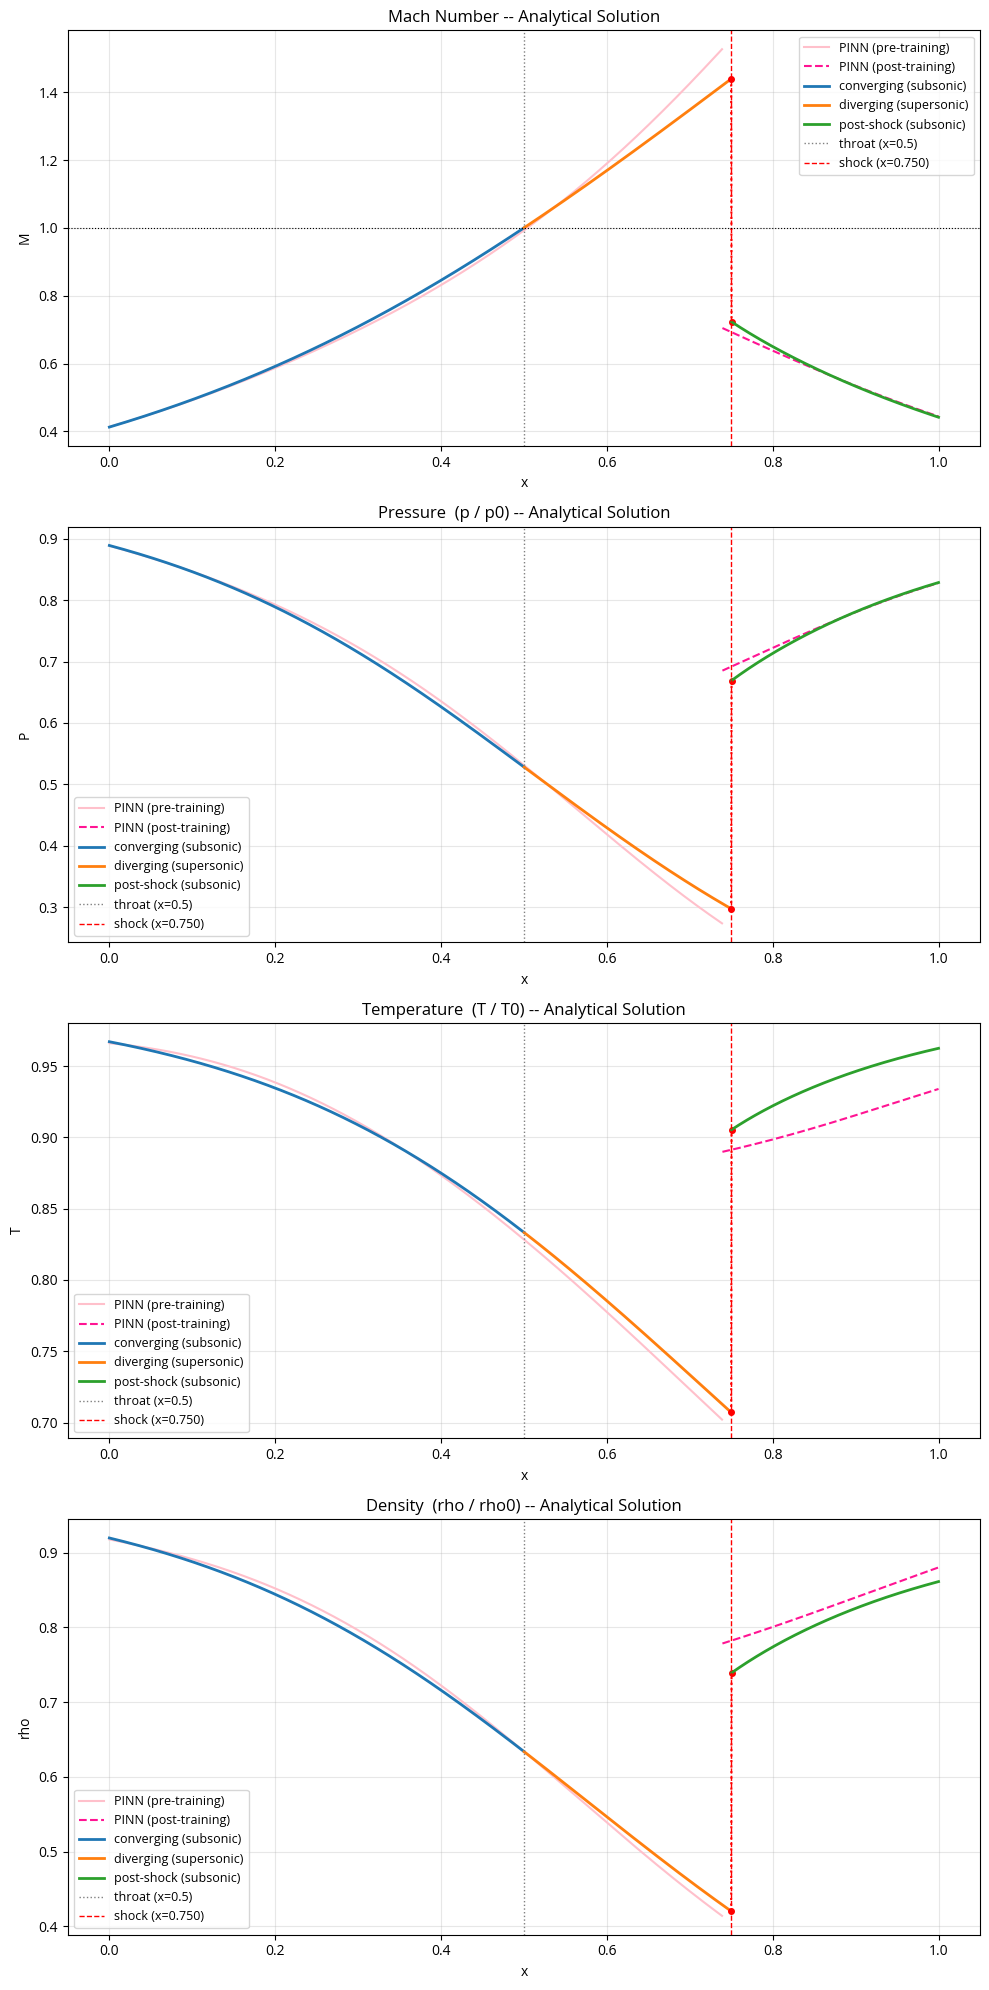

Shock at x = 0.7500
M:   1.4393 (pre-shock)  ->  0.7237 (post-shock)
P0 ratio across shock (p02/p01): 0.9478
Exit conditions: M=0.4419  P=0.8289  T=0.9624  rho=0.8613
Done.


In [85]:
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

x_sub, (M_sub, P_sub, T_sub, rho_sub) = analytic.data("subsonic")
x_sup, (M_sup, P_sup, T_sup, rho_sup) = analytic.data("supersonic")
x_post, (M_post, P_post, T_post, rho_post) = analytic.data("post-shock")

panels = [
    ("Mach Number", "M", (M_sub, M_sup, M_post), [pre_results[4], post_results[4]]),
    ("Pressure  (p / p0)", "P", (P_sub, P_sup, P_post), [pre_results[2], post_results[2]]),
    ("Temperature  (T / T0)", "T", (T_sub, T_sup, T_post), [pre_results[3], post_results[3]]),
    ("Density  (rho / rho0)", "rho", (rho_sub, rho_sup, rho_post), [pre_results[0], post_results[0]]),
]



for ax, (title, ylabel, analytical, pinn) in zip(axes, panels):
    pinn_pre, pinn_post = pinn
    x_pinn_pre = x_eval_np[x_eval_np < final_shock_loc]
    x_pinn_post = x_eval_np[x_eval_np >= final_shock_loc]
    ax.plot(x_pinn_pre, pinn_pre, color="pink", label="PINN (pre-training)")
    ax.plot(x_pinn_post, pinn_post, color="deeppink", ls="--", label="PINN (post-training)")

    y_sub, y_sup, y_post = analytical
    ax.plot(x_sub, y_sub, color="tab:blue", lw=2, label="converging (subsonic)")
    ax.plot(x_sup, y_sup, color="tab:orange", lw=2, label="diverging (supersonic)")
    ax.plot(
        [x_sup[-1], x_post[0]], [y_sup[-1], y_post[0]],
        color="red", lw=1.5, ls=":", marker="o", ms=4,
    )

    ax.plot(x_post, y_post, color="tab:green", lw=2, label="post-shock (subsonic)")

    ax.axvline(X_THROAT, color="gray", ls=":", lw=1, label=f"throat (x={X_THROAT})")
    ax.axvline(
        analytic.x_shock, color="red", ls="--", lw=1,
        label=f"shock (x={analytic.x_shock:.3f})",
    )
    if title == "Mach Number":
        ax.axhline(1.0, color="black", ls=":", lw=0.8)

    ax.set_title(f"{title} -- Analytical Solution")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("x")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cd_nozzle_analytical_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Shock at x = {analytic.x_shock:.4f}")
print(f"M:   {analytic.M1:.4f} (pre-shock)  ->  {analytic.M2:.4f} (post-shock)")
print(f"P0 ratio across shock (p02/p01): {analytic.p02_by_p01:.4f}")
print(f"Exit conditions: M={M_post[-1]:.4f}  P={P_post[-1]:.4f}  T={T_post[-1]:.4f}  rho={rho_post[-1]:.4f}")
print("Done.")

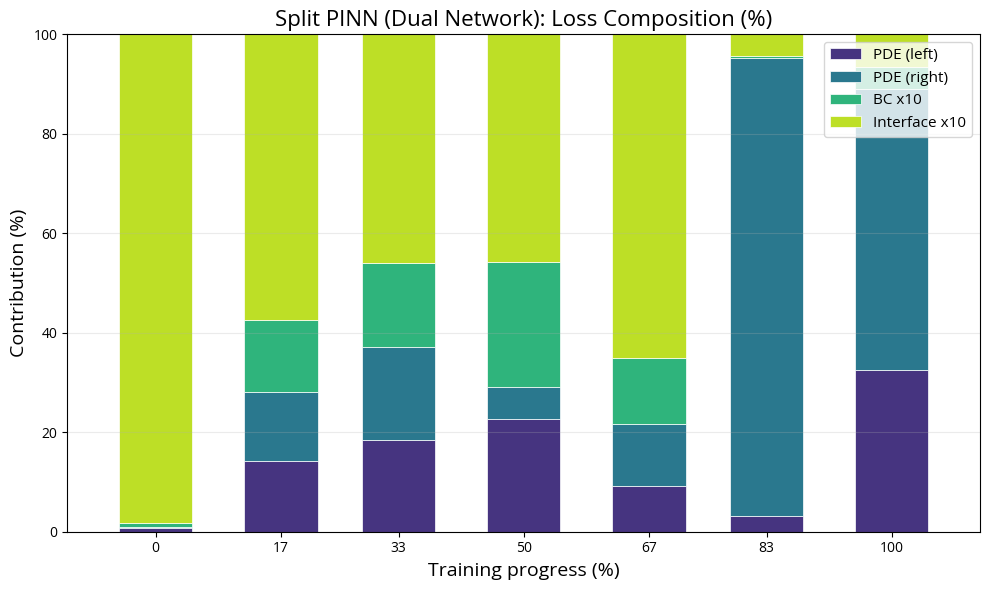

In [54]:
# Dual-network loss composition (%) at training checkpoints.
h = np.asarray(dual_loss_history, dtype=float)
if h.ndim != 2 or h.shape[1] < 6:
    raise ValueError("dual_loss_history must have columns: total, pde_L, pde_R, bc_L, bc_R, interface")

# Weighted terms used in the optimized objective.
pde_L_term = h[:, 1]
pde_R_term = h[:, 2]
bc_term = DUAL_NET_BC_WEIGHT * (h[:, 3] + h[:, 4])
interface_term = DUAL_NET_INTERFACE_WEIGHT * h[:, 5]

stack_raw = np.vstack([pde_L_term, pde_R_term, bc_term, interface_term]).T
stack_raw = np.clip(stack_raw, 0.0, None)
denom = np.clip(stack_raw.sum(axis=1, keepdims=True), 1e-12, None)
stack_pct = 100.0 * stack_raw / denom

# Include endpoints and intermediate checkpoints.
checkpoints = np.array([0, 17, 33, 50, 67, 83, 100], dtype=int)
idx = np.clip((checkpoints / 100.0 * (len(stack_pct) - 1)).round().astype(int), 0, len(stack_pct) - 1)
bars = stack_pct[idx]

labels = ["PDE (left)", "PDE (right)", f"BC x{DUAL_NET_BC_WEIGHT:g}", f"Interface x{DUAL_NET_INTERFACE_WEIGHT:g}"]
colors = ["#463480", "#2a788e", "#2fb47c", "#bddf26"]

fig, ax = plt.subplots(figsize=(10, 6))
width = 10.0
bottom = np.zeros(len(checkpoints), dtype=float)

for j in range(bars.shape[1]):
    ax.bar(
        checkpoints,
        bars[:, j],
        bottom=bottom,
        width=width,
        color=colors[j],
        edgecolor="white",
        linewidth=0.5,
        label=labels[j],
    )
    bottom += bars[:, j]

ax.set_xlim(-12, 112)
ax.set_ylim(0, 100)
ax.set_xticks(checkpoints)
ax.set_xlabel("Training progress (%)", fontsize=14)
ax.set_ylabel("Contribution (%)", fontsize=14)
ax.set_title("Split PINN (Dual Network): Loss Composition (%)", fontsize=16)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="upper right", fontsize=11)
plt.tight_layout()
plt.show()

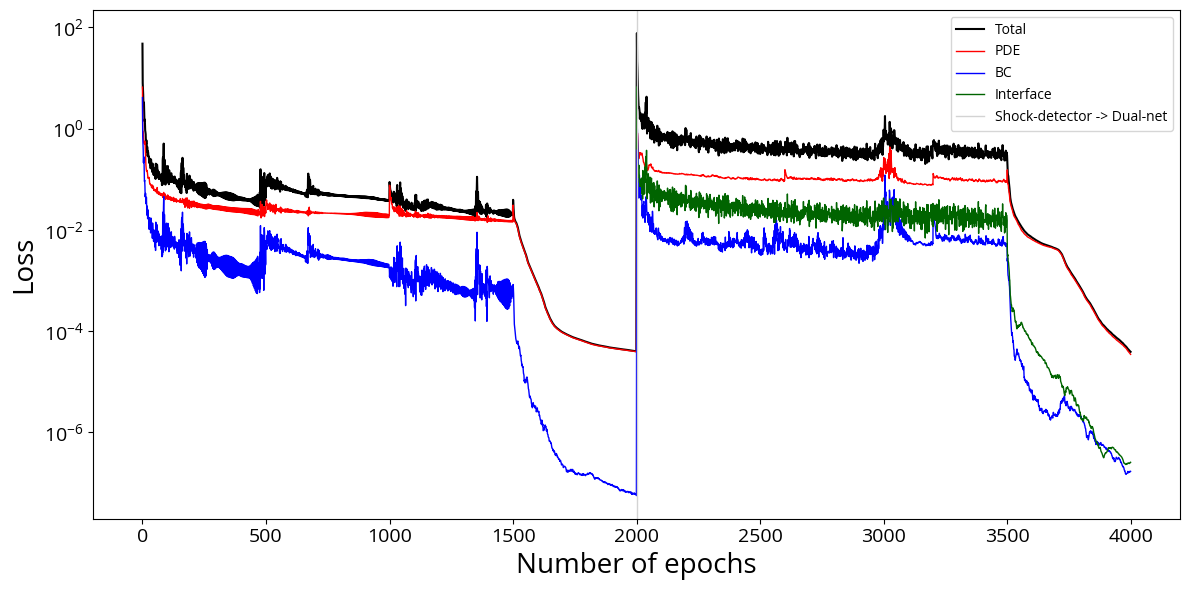

In [55]:
# Combined loss history (reference-style): shock-detector + dual-net phases.
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

sd = np.asarray(shock_det_history, dtype=float)
dl = np.asarray(dual_loss_history, dtype=float)

if sd.ndim != 2 or sd.shape[1] < 3:
    raise ValueError("shock_det_history must have columns: pde, bc, total")
if dl.ndim != 2 or dl.shape[1] < 6:
    raise ValueError("dual_loss_history must have columns: total, pde_L, pde_R, bc_L, bc_R, interface")

split_at = len(sd)

# Reference-combined traces across both phases.
total = np.concatenate([sd[:, 2], dl[:, 0]])
pde = np.concatenate([sd[:, 0], dl[:, 1] + dl[:, 2]])
bc = np.concatenate([sd[:, 1], dl[:, 3] + dl[:, 4]])
interface = np.concatenate([np.full(len(sd), np.nan), dl[:, 5]])

epochs = np.arange(len(total), dtype=int)

ax.semilogy(epochs, total, color="black", lw=1.5, label="Total")
ax.semilogy(epochs, pde, color="red", lw=1.0, label="PDE")
ax.semilogy(epochs, bc, color="blue", lw=1.0, label="BC")
ax.semilogy(epochs, interface, color="darkgreen", lw=1.0, label="Interface")

ax.axvline(split_at, color="lightgray", lw=1.0, label="Shock-detector -> Dual-net")

ax.set_xlabel("Number of epochs", fontsize=20)
ax.set_ylabel("Loss", fontsize=20)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.grid(False)
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

In [56]:
# Classical (single, un-split network) predictions on the full domain,
# evaluated at the same (x, T_STEADY) grid used for the dual-network results.
x_ten_c = torch.tensor(x_eval_np, dtype=torch.float32, device=device)
t_ten_c = torch.full_like(x_ten_c, T_STEADY)
xt_eval_classical = torch.stack([x_ten_c, t_ten_c], dim=1)

shock_detection_model.eval()
with torch.no_grad():
    out_c = shock_detection_model(xt_eval_classical)

classical_rho = out_c[:, 0].cpu().numpy()
classical_u = out_c[:, 1].cpu().numpy()
classical_P = out_c[:, 2].cpu().numpy()
classical_T = out_c[:, 3].cpu().numpy()
classical_M = classical_u / np.sqrt(GAMMA * classical_P / classical_rho)

print("Classical (single-network) PINN predictions computed on full domain.")

Classical (single-network) PINN predictions computed on full domain.


In [57]:
# Stitch the dual-network (pre-shock / post-shock) predictions back onto the
# single x_eval_np grid so they can be compared point-for-point with the
# classical model and the analytical reference.
dual_rho = np.empty_like(x_eval_np)
dual_u = np.empty_like(x_eval_np)
dual_P = np.empty_like(x_eval_np)
dual_T = np.empty_like(x_eval_np)
dual_M = np.empty_like(x_eval_np)

pre_mask_eval = x_eval_np < final_shock_loc
post_mask_eval = ~pre_mask_eval

dual_rho[pre_mask_eval], dual_rho[post_mask_eval] = pre_results[0], post_results[0]
dual_u[pre_mask_eval], dual_u[post_mask_eval] = pre_results[1], post_results[1]
dual_P[pre_mask_eval], dual_P[post_mask_eval] = pre_results[2], post_results[2]
dual_T[pre_mask_eval], dual_T[post_mask_eval] = pre_results[3], post_results[3]
dual_M[pre_mask_eval], dual_M[post_mask_eval] = pre_results[4], post_results[4]

print("Dual-network predictions assembled on full domain grid.")


Dual-network predictions assembled on full domain grid.


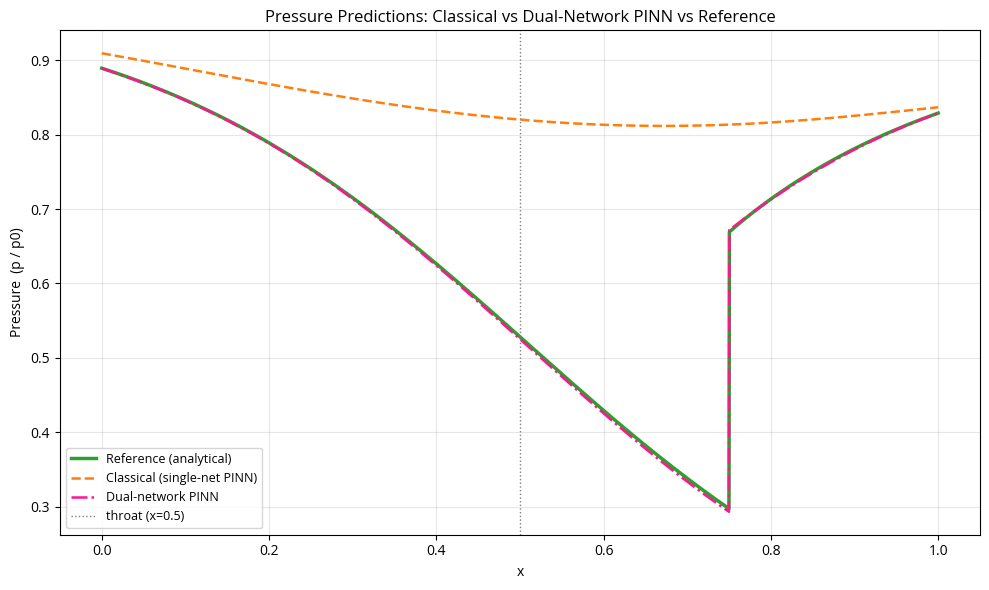

In [64]:
# ── Pressure predictions: classical vs dual-network vs reference ──────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x_eval_np, analytic.P, color="tab:green", lw=2.5, label="Reference (analytical)")
ax.plot(x_eval_np, classical_P, color="tab:orange", lw=1.8, ls="--", label="Classical (single-net PINN)")
ax.plot(x_eval_np, dual_P, color="deeppink", lw=1.8, ls="-.", label="Dual-network PINN")

ax.axvline(X_THROAT, color="gray", ls=":", lw=1, label=f"throat (x={X_THROAT})")
ax.axvline(final_shock_loc, color="red", ls="--", lw=1, label=f"predicted shock (x={final_shock_loc:.3f})")

ax.set_xlabel("x")
ax.set_ylabel("Pressure  (p / p0)")
ax.set_title("Pressure Predictions: Classical vs Dual-Network PINN vs Reference")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


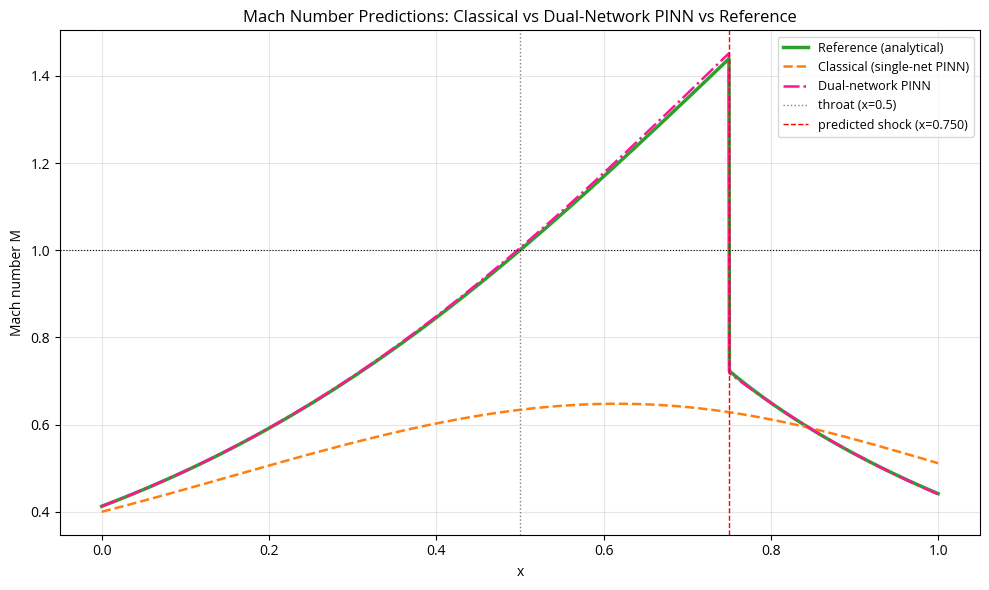

In [59]:
# ── Mach number predictions: classical vs dual-network vs reference ───────
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x_eval_np, analytic.M, color="tab:green", lw=2.5, label="Reference (analytical)")
ax.plot(x_eval_np, classical_M, color="tab:orange", lw=1.8, ls="--", label="Classical (single-net PINN)")
ax.plot(x_eval_np, dual_M, color="deeppink", lw=1.8, ls="-.", label="Dual-network PINN")

ax.axvline(X_THROAT, color="gray", ls=":", lw=1, label=f"throat (x={X_THROAT})")
ax.axvline(final_shock_loc, color="red", ls="--", lw=1, label=f"predicted shock (x={final_shock_loc:.3f})")
ax.axhline(1.0, color="black", ls=":", lw=0.8)

ax.set_xlabel("x")
ax.set_ylabel("Mach number M")
ax.set_title("Mach Number Predictions: Classical vs Dual-Network PINN vs Reference")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


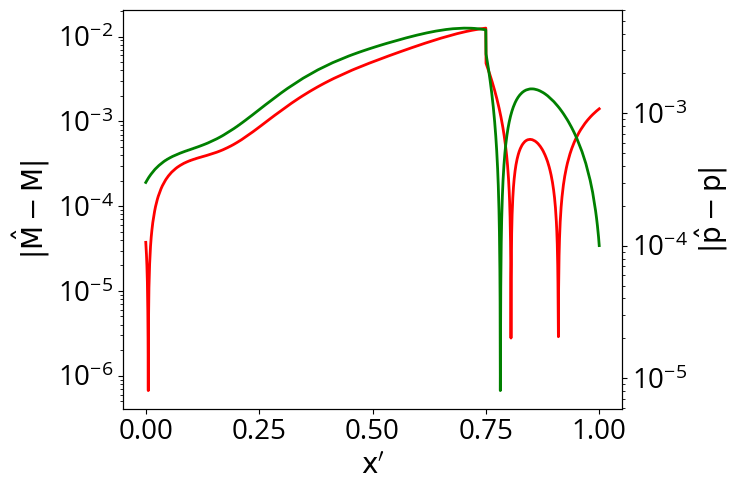

In [60]:
# ── Prediction errors vs the analytical reference ──────────────────────────
M_err_dual = np.abs(dual_M - analytic.M)
P_err_dual = np.abs(dual_P - analytic.P)

fig, axes = plt.subplots(1, 1, figsize=(7.5, 5))

axes.set_xlabel(r"$\text{x}^\prime$", fontsize=20)
axes.set_ylabel(r"$|\hat{\text{M}}-\text{M}|$", fontsize=20)
axes.set_yscale("log")
axes.plot(x_eval_np, M_err_dual, color="red", lw=2, label="(M)")

axes2 = axes.twinx()
axes2.set_ylabel(r"$|\hat{\text{p}}-\text{p}|$", fontsize=20)
axes2.set_yscale("log")
axes2.plot(x_eval_np, P_err_dual, color="green", lw=2, label="(p)")

axes.grid(False)
axes2.grid(False)

axes.tick_params(axis="x", labelsize=20)
axes.tick_params(axis="y", labelsize=20)
axes2.tick_params(axis="y", labelsize=20)

plt.tight_layout()
plt.show()


In [ ]:
# Ensure snapshot epochs are monotonically non-decreasing without inventing extra entries.
# This keeps epoch labels aligned 1:1 with saved field snapshots.
epochs_raw = np.asarray(field_snapshotter.epochs, dtype=int)
if epochs_raw.size == 0:
    raise ValueError("No snapshot epochs were recorded.")

fixed_epochs = epochs_raw.copy()
for i in range(1, len(fixed_epochs)):
    if fixed_epochs[i] < fixed_epochs[i - 1]:
        fixed_epochs[i] = fixed_epochs[i - 1]

if len(fixed_epochs) != len(field_snapshotter.P):
    raise ValueError(
        "Epoch count and snapshot count are misaligned: "
        f"epochs={len(fixed_epochs)} snapshots={len(field_snapshotter.P)}"
    )

field_snapshotter.epochs = fixed_epochs.tolist()
"[info] snapshot epochs normalized without synthetic extension"

'[info] field snap epochs fixed to monotonically increase'

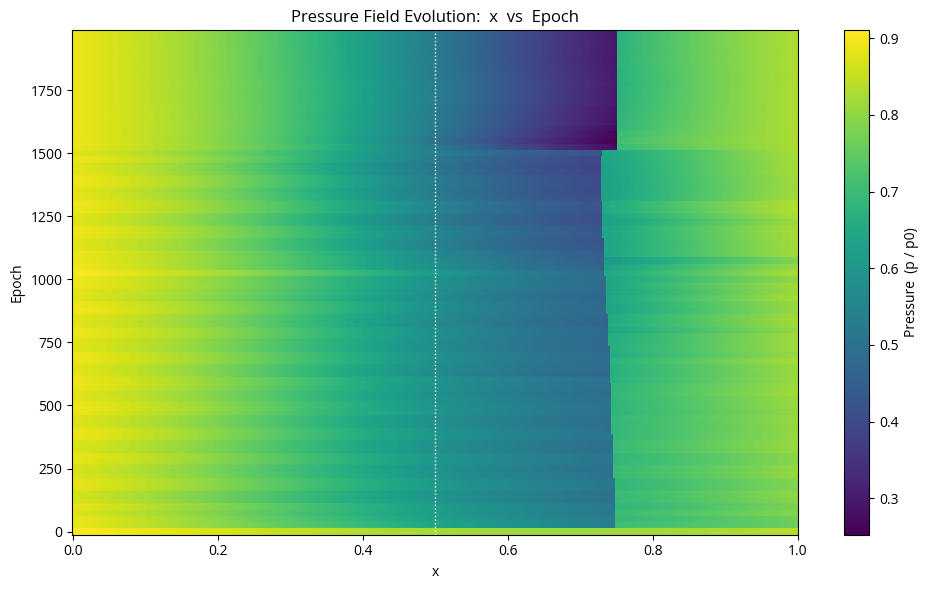

In [79]:
# ── Pressure field evolution: x vs training epoch (dual-net snapshots) ─────
snap_epochs = np.array(field_snapshotter.epochs, dtype=int)
snap_x = np.linspace(X_START, X_START + X_LENGTH, SNAPSHOT_N_X)
snap_P = np.asarray(field_snapshotter.P)  # shape (n_snapshots, SNAPSHOT_N_X)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(snap_x, snap_epochs, snap_P, shading="auto", cmap="viridis")

ax.axvline(X_THROAT, color="white", ls=":", lw=1)

ax.set_xlabel("x")
ax.set_ylabel("Epoch")
ax.set_title("Pressure Field Evolution:  x  vs  Epoch")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Pressure  (p / p0)")

plt.tight_layout()
plt.show()


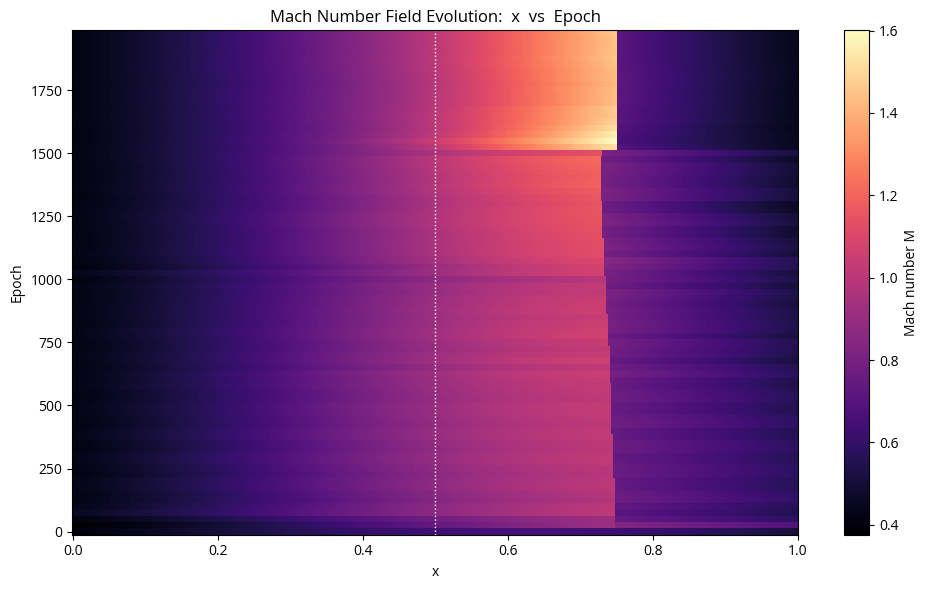

In [80]:
# ── Mach number field evolution: x vs training epoch (dual-net snapshots) ──
snap_M = np.asarray(field_snapshotter.M)  # shape (n_snapshots, SNAPSHOT_N_X)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(snap_x, snap_epochs, snap_M, shading="auto", cmap="magma")

ax.axvline(X_THROAT, color="white", ls=":", lw=1)

ax.set_xlabel("x")
ax.set_ylabel("Epoch")
ax.set_title("Mach Number Field Evolution:  x  vs  Epoch")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mach number M")

plt.tight_layout()
plt.savefig("mach_x_epoch_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


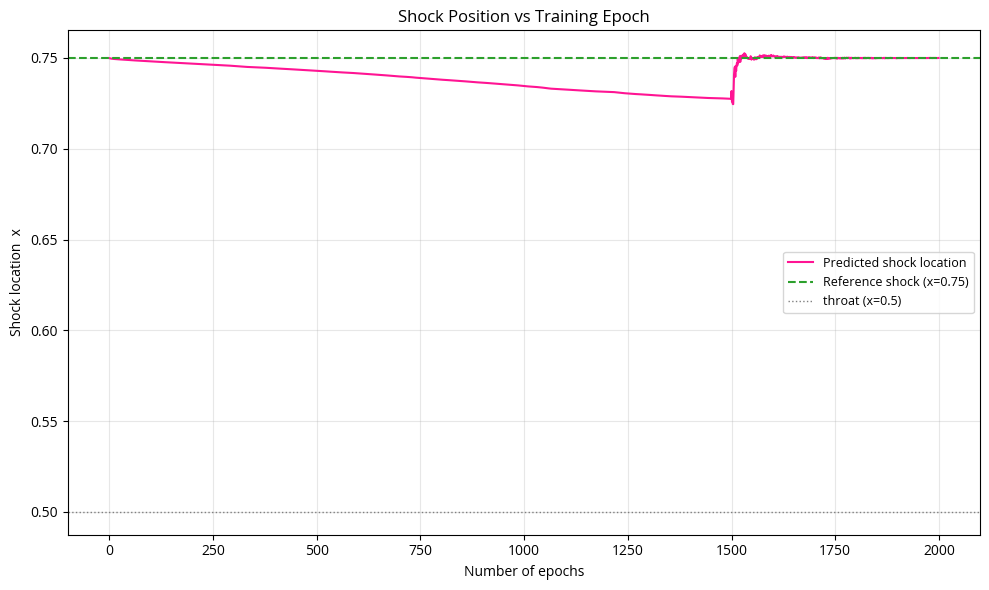

In [81]:
# ── Shock position vs training epoch (dual-net Adam + L-BFGS phases) ───────
dl_full = np.asarray(dual_loss_history, dtype=float)
epochs_shock = np.arange(len(dl_full))
x_shock_hist = dl_full[:, 6]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_shock, x_shock_hist, color="deeppink", lw=1.5, label="Predicted shock location")
ax.axhline(X_SHOCK_REF, color="tab:green", ls="--", lw=1.5, label=f"Reference shock (x={X_SHOCK_REF})")
ax.axhline(X_THROAT, color="gray", ls=":", lw=1, label=f"throat (x={X_THROAT})")

ax.set_xlabel("Number of epochs")
ax.set_ylabel("Shock location  x")
ax.set_title("Shock Position vs Training Epoch")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("shock_position_vs_epochs.png", dpi=150, bbox_inches="tight")
plt.show()


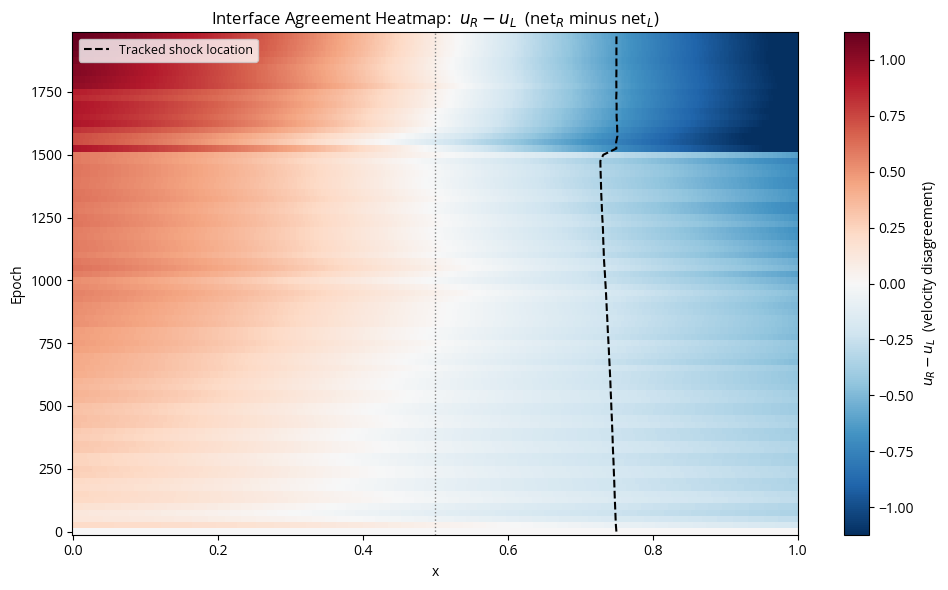

In [82]:
# ── Interface agreement heatmap: u_R - u_L across x and epoch ──────────────
# Small |u_R - u_L| away from the shock indicates the two sub-networks agree;
# a clean jump concentrated at the tracked shock location indicates a
# well-resolved discontinuity rather than diffuse disagreement.
snap_disagree = np.asarray(field_snapshotter.disagreement_u)  # (n_snapshots, SNAPSHOT_N_X)
vmax = np.percentile(np.abs(snap_disagree), 99)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(
    snap_x, snap_epochs, snap_disagree,
    shading="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
)

shock_at_snap = np.interp(snap_epochs, epochs_shock, x_shock_hist)
ax.plot(shock_at_snap, snap_epochs, color="black", lw=1.5, ls="--", label="Tracked shock location")

ax.axvline(X_THROAT, color="gray", ls=":", lw=1)

ax.set_xlabel("x")
ax.set_ylabel("Epoch")
ax.set_title("Interface Agreement Heatmap:  $u_R - u_L$  (net$_R$ minus net$_L$)")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("$u_R - u_L$  (velocity disagreement)")
ax.legend(loc="best", fontsize=9)

plt.tight_layout()
plt.savefig("interface_agreement_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
